# Fase 2 - Analise Exploratoria (EDA)

MG multi-ano com foco no **Pacote A**:
- Distribuicao bruta e alvo `desfecho` (Fatal | Ferido)
- Variaveis de contexto (`COLUNAS_CONTEXTO`)
- Hipoteses H1-H5 para regras contexto -> Fatal

In [6]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import (
    ANOS_OCORRENCIA,
    COLUNAS_CONTEXTO,
    DATA_DIR,
    DADOS_DIR,
    FIGURAS_DIR,
    FILTRO_UF,
    MIN_SUPPORT,
    PROCESSED_DIR,
    TABELAS_DIR,
)

plt.rcParams["figure.figsize"] = (11, 5)
sns.set_style("whitegrid")
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

from src.data_loading import carregar_anos, resumo_por_ano
from src.preparation import criar_desfecho, criar_fim_de_semana, subset_com_vitimas

df, _ = carregar_anos(ignorar_ausentes=True)
resumo = resumo_por_ano(df)

[OK] Anos carregados: [2023, 2024, 2025, 2026] | Registros: 30,858


## 2.1 Visao geral multi-ano

Periodo: 2023-2026 | Ocorrencias: 30,858


,ano,n_ocorrencias,pct_fatais,pct_com_vitimas,arquivo
0,2023,9007,6.75,87.33,datatran2023.csv
1,2024,9296,6.88,87.04,datatran2024.csv
2,2025,9570,6.76,87.39,datatran2025.csv
3,2026,2985,7.07,86.40,datatran2026.csv


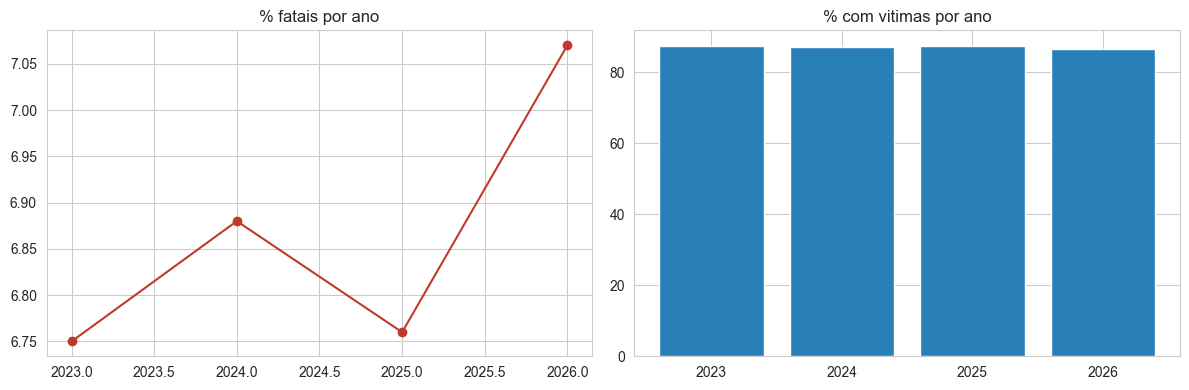

In [7]:
print(f"Periodo: {df['ano'].min()}-{df['ano'].max()} | Ocorrencias: {len(df):,}")
display(resumo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(resumo["ano"], resumo["pct_fatais"], marker="o", color="#c0392b")
axes[0].set_title("% fatais por ano")
axes[1].bar(resumo["ano"].astype(str), resumo["pct_com_vitimas"], color="#2980b9")
axes[1].set_title("% com vitimas por ano")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "02_tendencia_anual.png", dpi=200)
plt.show()

## 2.2 Classificacao bruta vs. desfecho

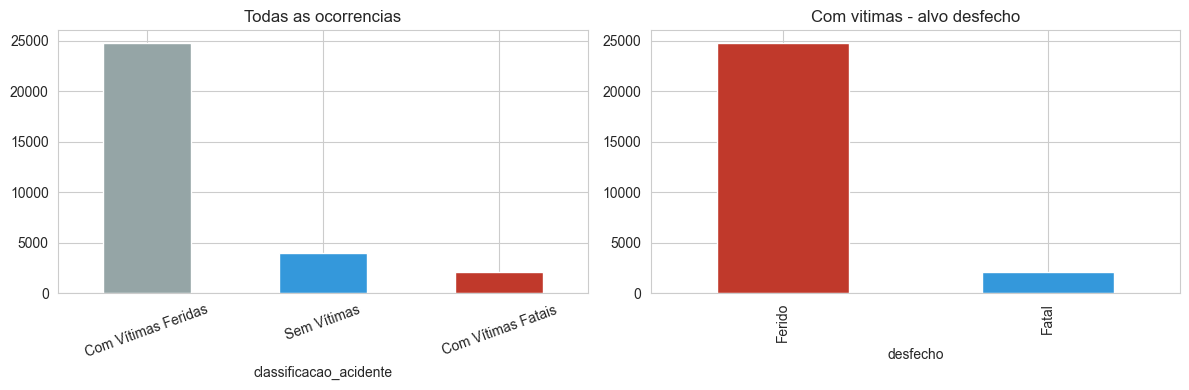

Base com vitimas: 26,899 (87.2% do total)
Desbalanceamento: Fatal 7.83% | Ferido 92.17%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["classificacao_acidente"].value_counts().plot(kind="bar", ax=axes[0], color=["#95a5a6", "#3498db", "#c0392b"])
axes[0].set_title("Todas as ocorrencias")
axes[0].tick_params(axis="x", rotation=20)

df_cv = subset_com_vitimas(df).copy()
df_cv["desfecho"] = criar_desfecho(df_cv)
df_cv["desfecho"].value_counts().plot(kind="bar", ax=axes[1], color=["#c0392b", "#3498db"])
axes[1].set_title("Com vitimas - alvo desfecho")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "02_classificacao_vs_desfecho.png", dpi=200)
plt.show()

pct_fatal = (df_cv["desfecho"] == "Fatal").mean() * 100
print(f"Base com vitimas: {len(df_cv):,} ({len(df_cv)/len(df)*100:.1f}% do total)")
print(f"Desbalanceamento: Fatal {pct_fatal:.2f}% | Ferido {100-pct_fatal:.2f}%")

## 2.3 Analise temporal

desfecho,Fatal,Ferido
fase_dia,,
Amanhecer,12.3,87.7
Plena Noite,11.2,88.8
Anoitecer,7.8,92.2
Pleno dia,5.7,94.3


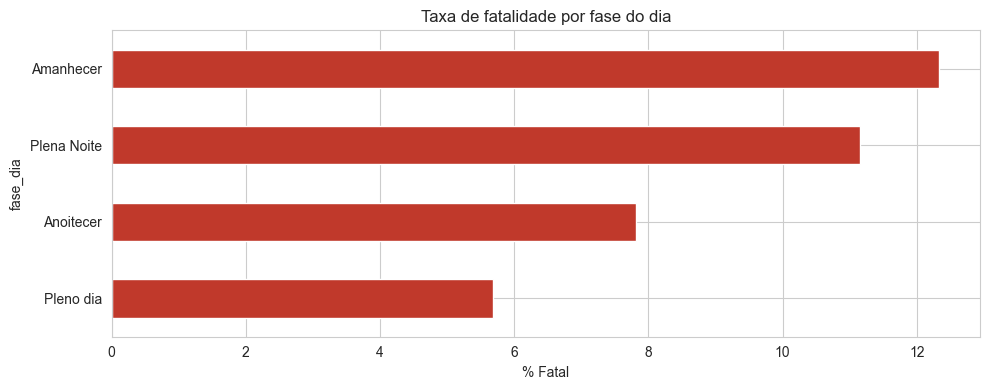

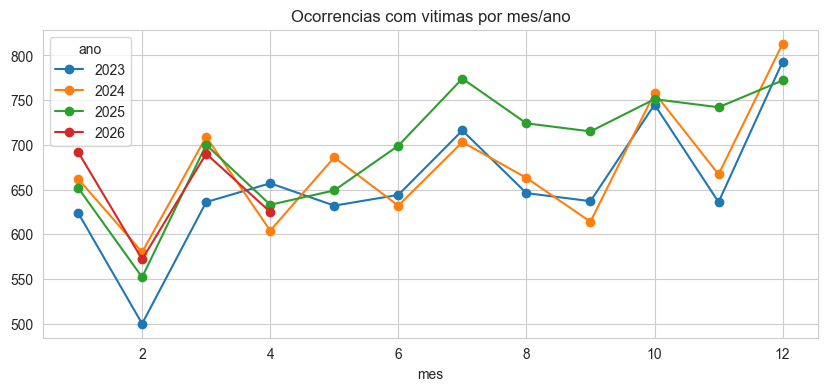

In [9]:
df_cv["mes"] = df_cv["data_inversa"].dt.month
df_cv["fim_de_semana"] = criar_fim_de_semana(df_cv)

ct_fase = pd.crosstab(df_cv["fase_dia"], df_cv["desfecho"], normalize="index") * 100
display(ct_fase.sort_values("Fatal", ascending=False).round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ct_fase["Fatal"].sort_values(ascending=True).plot(kind="barh", ax=ax, color="#c0392b")
ax.set_xlabel("% Fatal")
ax.set_title("Taxa de fatalidade por fase do dia")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "02_fatal_por_fase_dia.png", dpi=200)
plt.show()

mensal = df_cv.groupby(["ano", "mes"]).size().reset_index(name="n")
mensal.pivot(index="mes", columns="ano", values="n").plot(figsize=(10, 4), marker="o")
plt.title("Ocorrencias com vitimas por mes/ano")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "02_sazonalidade_mensal.png", dpi=200)
plt.show()

## 2.4 Analise geografica

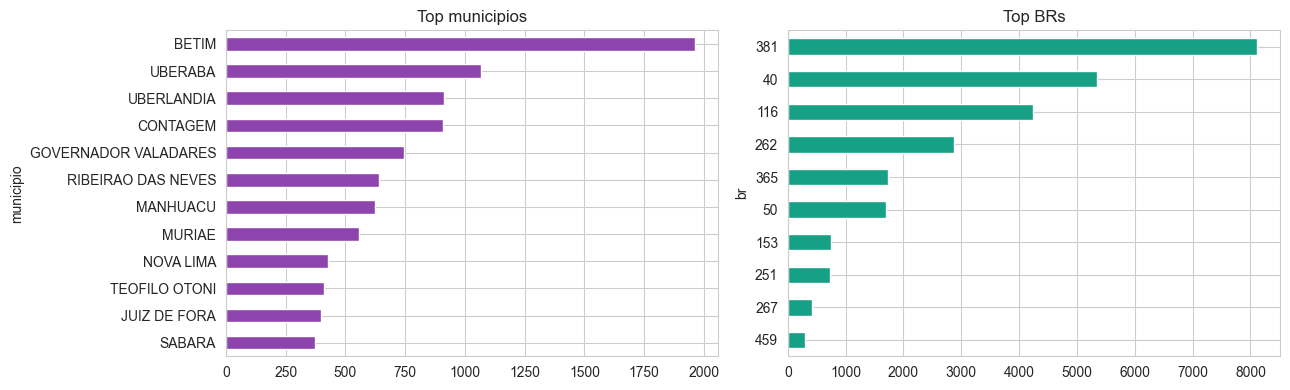

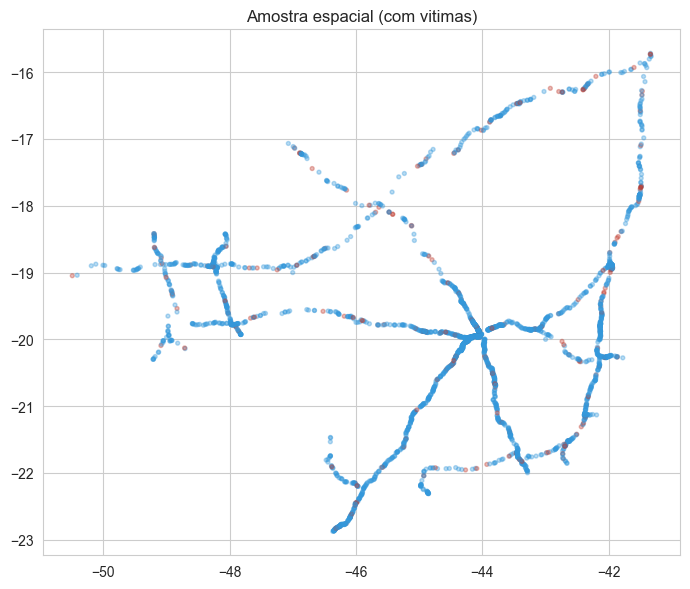

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_cv["municipio"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[0], color="#8e44ad")
axes[0].set_title("Top municipios")
df_cv["br"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[1], color="#16a085")
axes[1].set_title("Top BRs")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "02_geo_top_mun_br.png", dpi=200)
plt.show()

geo = df_cv.copy()
geo["latitude"] = pd.to_numeric(geo["latitude"], errors="coerce")
geo["longitude"] = pd.to_numeric(geo["longitude"], errors="coerce")

if geo["latitude"].notna().sum() > 100:
    sample = geo.dropna(subset=["latitude", "longitude"]).sample(min(3000, len(geo)), random_state=42)
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = sample["desfecho"].map({"Fatal": "#c0392b", "Ferido": "#3498db"})
    ax.scatter(sample["longitude"].astype(float), sample["latitude"].astype(float), c=colors, alpha=0.35, s=8)
    ax.set_title("Amostra espacial (com vitimas)")
    fig.tight_layout()
    fig.savefig(FIGURAS_DIR / "02_mapa_amostra.png", dpi=200)
    plt.show()

## 2.5 Variaveis categ?ricas de contexto

In [11]:
for col in COLUNAS_CONTEXTO:
    ct = pd.crosstab(df_cv[col], df_cv["desfecho"])
    ct["pct_fatal"] = (ct.get("Fatal", 0) / ct.sum(axis=1) * 100).round(1)
    print(f"\n=== {col} (top 5 % fatal) ===")
    display(ct.sort_values("pct_fatal", ascending=False).head(5))


=== condicao_metereologica (top 5 % fatal) ===


desfecho,Fatal,Ferido,pct_fatal
condicao_metereologica,,,
Nevoeiro/Neblina,23,143,13.9
Vento,7,49,12.5
Ignorado,29,323,8.2
Céu Claro,1337,15004,8.2
Nublado,336,3909,7.9



=== tipo_pista (top 5 % fatal) ===


desfecho,Fatal,Ferido,pct_fatal
tipo_pista,,,
Simples,1395,12313,10.2
Dupla,662,11389,5.5
Múltipla,49,1091,4.3



=== tracado_via (top 5 % fatal) ===


...

desfecho,Fatal,Ferido,pct_fatal
tipo_acidente,,,
Colisão frontal,581,1297,30.9
Atropelamento de Pedestre,348,878,28.4
Colisão lateral sentido oposto,73,724,9.2
Colisão transversal,161,2638,5.8
Eventos atípicos,5,82,5.7



=== fase_dia (top 5 % fatal) ===


desfecho,Fatal,Ferido,pct_fatal
fase_dia,,,
Amanhecer,169,1202,12.3
Plena Noite,929,7397,11.2
Anoitecer,109,1286,7.8
Pleno dia,899,14908,5.7



=== fim_de_semana (top 5 % fatal) ===


desfecho,Fatal,Ferido,pct_fatal
fim_de_semana,,,
Sim,762,7985,8.7
Não,1344,16808,7.4


## 2.6 Cramer's V (contexto x desfecho)

,variavel,cramers_v
5,tipo_acidente,0.301
4,causa_acidente,0.251
2,tracado_via,0.116
6,fase_dia,0.100
1,tipo_pista,0.090
3,uso_solo,0.079
0,condicao_metereologica,0.034
7,fim_de_semana,0.023


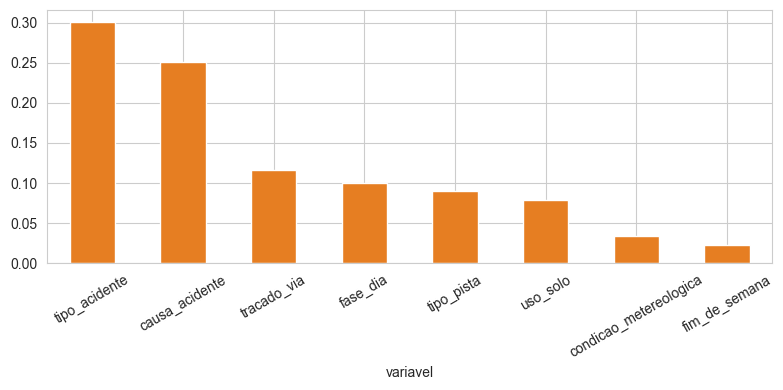

In [12]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return (chi2 / (n * min(r - 1, k - 1))) ** 0.5

cv_df = pd.DataFrame([
    {"variavel": col, "cramers_v": round(cramers_v(df_cv[col], df_cv["desfecho"]), 3)}
    for col in COLUNAS_CONTEXTO
]).sort_values("cramers_v", ascending=False)
display(cv_df)

fig, ax = plt.subplots(figsize=(8, 4))
cv_df.plot(x="variavel", y="cramers_v", kind="bar", ax=ax, legend=False, color="#e67e22")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "02_cramers_v_desfecho.png", dpi=200)
plt.show()

## 2.7 Hipoteses H1-H5

| ID | Hipotese |
|----|----------|
| H1 | Plena Noite + Pista Simples + rural elevam risco de Fatal |
| H2 | Fim de semana + noite tem padroes distintos |
| H3 | Colisao frontal e atropelamento associam-se a Fatal |
| H4 | Meteorologia adversa + pista influenciam desfecho |
| H5 | Padroes diferem entre urbano e rural |

**Excluidos da mineracao:** gravidade_binaria, classificacao_acidente, faixa_horaria, dia_semana.

## 2.8 Implicacoes para o pipeline

In [13]:
print("Design Pacote A:")
print("  - Subset: com vitimas")
print("  - Alvo: desfecho_Fatal | desfecho_Ferido")
print("  - Antecedentes: apenas ctx_*")
print(f"  - Colunas: {COLUNAS_CONTEXTO}")
print(f"  - min_support: {MIN_SUPPORT}")
print("\nProximo: preparar_pipeline() no notebook 03")

Design Pacote A:
  - Subset: com vitimas
  - Alvo: desfecho_Fatal | desfecho_Ferido
  - Antecedentes: apenas ctx_*
  - Colunas: ['condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'causa_acidente', 'tipo_acidente', 'fase_dia', 'fim_de_semana']
  - min_support: 0.005

Proximo: preparar_pipeline() no notebook 03
